<a href="https://colab.research.google.com/github/IbragimovAbduaziz/predictive-banking-analytics/blob/main/predictive_banking_analytics_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 Bank Marketing: Mijoz muddatli depozit ochadimi? / Will the client subscribe to a term deposit?

**Maqsad / Goal:** bank qaysi mijozlarga **qo'ng'iroq qilishi** kerakligini oldindan aniqlash (qo'ng'iroq xarajatini kamaytirish, konversiyani oshirish).

Men bu loyihada dastlabki versiyamni qayta ko'rib chiqdim. Birinchi variantda bitta model (Random Forest) va 85% accuracy bor edi, lekin tahlil qilganimda ikkita jiddiy muammoni topdim:

1. **Data leakage:** `duration` (suhbat davomiyligi) qo'ng'iroq *tugagandan keyingina* ma'lum bo'ladi. Qo'ng'iroqdan oldin mijozni tanlash uchun uni ishlatib bo'lmaydi.
2. **Metodologiya:** `LabelEncoder` nominal ustunlarga soxta tartib beradi, bitta model bilan solishtirish yo'q, cross-validation yo'q, faqat accuracy ko'rilgan.



## 1-bosqich. Kutubxonalar va ma'lumotni yuklash / Imports & data loading

In [1]:
import warnings, json, os, joblib
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier, HistGradientBoostingClassifier)
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
os.makedirs('images', exist_ok=True)
RESULTS = {}

df = pd.read_csv('bank.csv')
print(f'Qatorlar: {df.shape[0]} | Ustunlar: {df.shape[1]}')
df.head()

Qatorlar: 11162 | Ustunlar: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## 2-bosqich. Dastlabki tekshiruv / Initial inspection

Modelga o'tishdan oldin ma'lumot sifatini tekshiraman: bo'sh kataklar, dublikatlar, target balansi va yashirin "bo'sh" qiymatlar (`unknown`).

In [2]:
print('Bo\'sh kataklar (NaN):', int(df.isnull().sum().sum()))
print('Dublikat qatorlar    :', int(df.duplicated().sum()))
print()
print('Target taqsimoti (deposit):')
print(df['deposit'].value_counts(normalize=True).round(3))
print()
# NaN yo'q, lekin "unknown" matn ko'rinishidagi yashirin bo'sh qiymatlar bor
unk = (df.select_dtypes(exclude='number') == 'unknown').sum()
print('"unknown" qiymatlar soni:')
print(unk[unk > 0])
print()
print('Manfiy balans    :', int((df['balance'] < 0).sum()), 'ta mijoz')
print('pdays == -1 ulushi:', round((df['pdays'] == -1).mean(), 3), '(oldin bog\'lanilmagan)')

Bo'sh kataklar (NaN): 0
Dublikat qatorlar    : 0

Target taqsimoti (deposit):
deposit
no     0.526
yes    0.474
Name: proportion, dtype: float64

"unknown" qiymatlar soni:
job            70
education     497
contact      2346
poutcome     8326
dtype: int64

Manfiy balans    : 688 ta mijoz
pdays == -1 ulushi: 0.746 (oldin bog'lanilmagan)


**Xulosa:** NaN va dublikat yo'q, target deyarli muvozanatli (~47% / 53%), shuning uchun class-imbalance texnikasi (SMOTE va h.k.) kerak emas. Lekin e'tibor beradigan joylar bor:
- `unknown` qiymatlari (ayniqsa `contact` va `poutcome`) aslida *yo'qolgan ma'lumot*. Men ularni alohida kategoriya sifatida qoldiraman, chunki "unknown" o'zi ham signal bo'lishi mumkin.
- `pdays = -1` degani "oldin bog'lanilmagan", bu oddiy son emas. Uni alohida belgi qilaman.
- Balans manfiy bo'lishi mumkin (qarz), shuning uchun oddiy `log` ishlamaydi.

## 3-bosqich. Vizual tahlil (EDA) / Exploratory analysis

Avvalgi versiyada `countplot` ishlatgan edim, lekin u mijozlar *soni*ni ko'rsatadi. Bizga kerakligi esa har bir guruhdagi **konversiya foizi**.

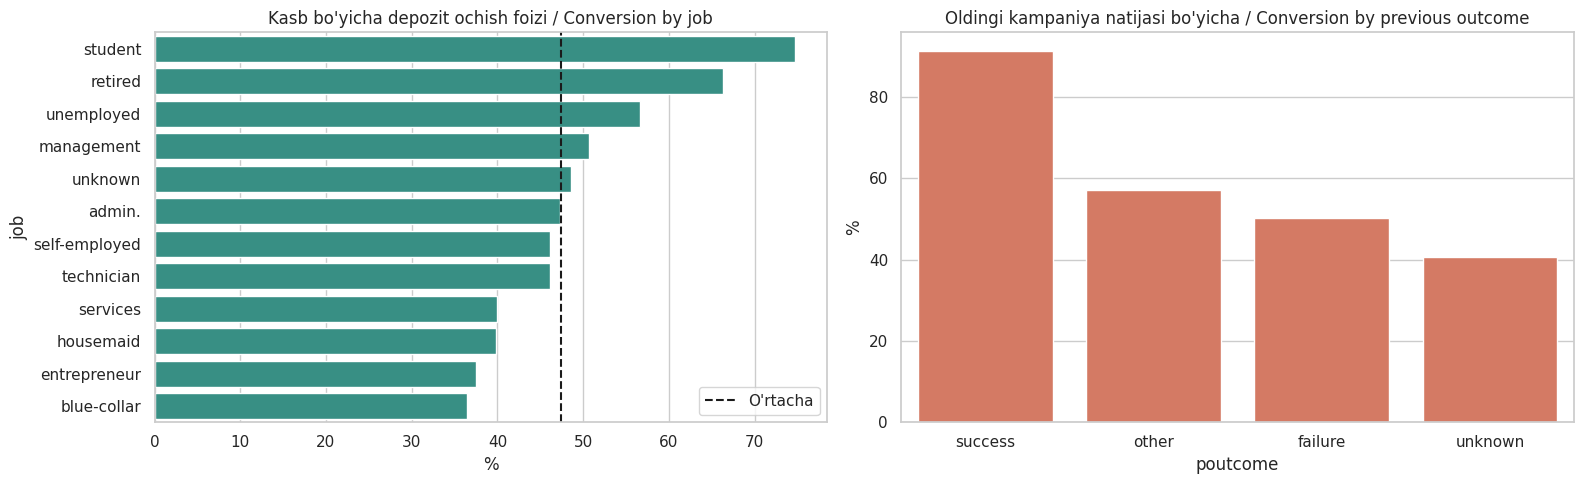

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df['target'] = (df['deposit'] == 'yes').astype(int)

job_rate = df.groupby('job')['target'].mean().sort_values(ascending=False)
sns.barplot(x=job_rate.values * 100, y=job_rate.index, ax=axes[0], color='#2a9d8f')
axes[0].axvline(df['target'].mean() * 100, color='k', ls='--', label='O\'rtacha')
axes[0].set_title('Kasb bo\'yicha depozit ochish foizi / Conversion by job')
axes[0].set_xlabel('%'); axes[0].legend()

pout = df.groupby('poutcome')['target'].mean().sort_values(ascending=False)
sns.barplot(x=pout.index, y=pout.values * 100, ax=axes[1], color='#e76f51')
axes[1].set_title('Oldingi kampaniya natijasi bo\'yicha / Conversion by previous outcome')
axes[1].set_ylabel('%')
plt.tight_layout(); plt.savefig('images/eda_job_poutcome.png', dpi=130); plt.show()

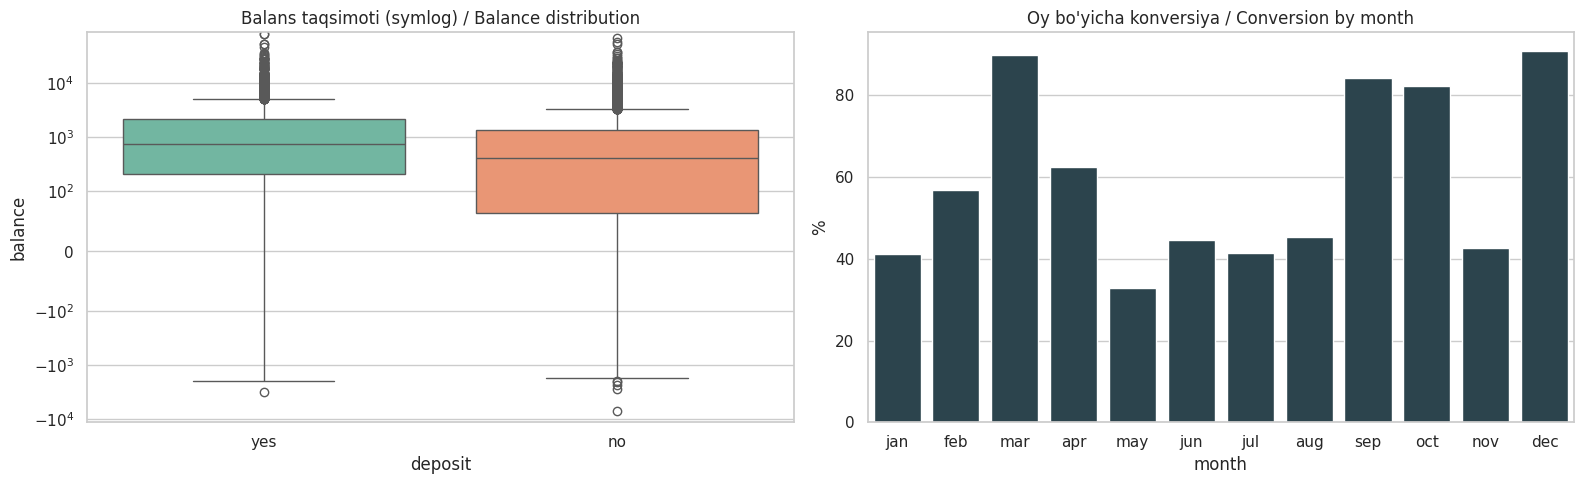

           mean  median  count
deposit                       
no       1280.2   414.0   5873
yes      1804.3   733.0   5289


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Balans: manfiy qiymatlar bor, shuning uchun log emas, 'symlog' shkalasi
sns.boxplot(data=df, x='deposit', y='balance', palette='Set2', ax=axes[0])
axes[0].set_yscale('symlog', linthresh=100)
axes[0].set_title('Balans taqsimoti (symlog) / Balance distribution')

month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
m = df.groupby('month')['target'].mean().reindex(month_order) * 100
sns.barplot(x=m.index, y=m.values, ax=axes[1], color='#264653')
axes[1].set_title('Oy bo\'yicha konversiya / Conversion by month')
axes[1].set_ylabel('%')
plt.tight_layout(); plt.savefig('images/eda_balance_month.png', dpi=130); plt.show()

print(df.groupby('deposit')['balance'].agg(['mean', 'median', 'count']).round(1))

**Kuzatuvlar:**
- Balansning *o'rtachasi* va *medianasi* o'rtasida katta farq bor, ya'ni ma'lumot o'ng tomonga cho'zilgan (outlier'lar). Shu sabab median ishonchliroq.
- Konversiya oylar bo'yicha keskin farq qiladi: mart, sentabr, oktabr, dekabrda yuqori, mayda past. Bu `month` muhim signal ekanini ko'rsatadi.
- Oldingi kampaniyada muvaffaqiyatli bo'lgan (`success`) mijozlar juda yuqori foizda rozi bo'ladi.

## 4-bosqich. Muhim muammo: `duration` va data leakage

`duration`: bank xodimi bilan **bo'lib o'tgan suhbat** davomiyligi (soniyada). U faqat qo'ng'iroq tugagach ma'lum bo'ladi. Agar maqsad "kimga qo'ng'iroq qilish kerak" ni *oldindan* aniqlash bo'lsa, bu ustun modelda bo'lmasligi kerak. Aks holda model "kelajakdan" ma'lumot olib, sun'iy ravishda yaxshi ko'rinadi.

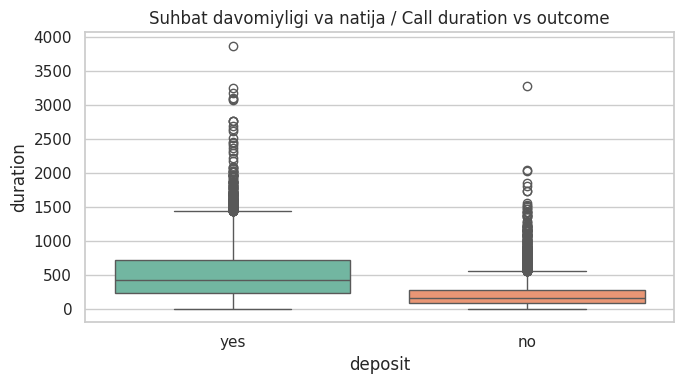

deposit
no     163.0
yes    426.0
Name: duration, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='deposit', y='duration', palette='Set2', ax=ax)
ax.set_title('Suhbat davomiyligi va natija / Call duration vs outcome')
plt.tight_layout(); plt.savefig('images/duration_leakage.png', dpi=130); plt.show()
print(df.groupby('deposit')['duration'].median())

## 5-bosqich. Feature engineering va Train/Test bo'lish

Muhim tartib: **avval bo'lish, keyin kodlash**. Avvalgi versiyada `LabelEncoder` butun datasetga qo'llangan edi. Bu juda katta xato emas, lekin to'g'ri amaliyot emas. Endi barcha preprocessing `Pipeline` ichida, faqat train ma'lumotida o'rganadi.

Yangi belgilar:
- `was_contacted`: oldin bog'lanilganmi (`pdays != -1`)
- `pdays`: `-1` qiymati `0` ga almashtiriladi (uning ma'nosini `was_contacted` olib yuradi)
- `log_balance`: belgisini saqlagan holda logarifm (`sign(x)*log1p(|x|)`), chiziqli modellar uchun foydali

In [6]:
X = df.drop(columns=['deposit', 'target']).copy()
y = df['target']

X['was_contacted'] = (X['pdays'] != -1).astype(int)
X['pdays'] = X['pdays'].replace(-1, 0)
X['log_balance'] = np.sign(X['balance']) * np.log1p(X['balance'].abs())

# Test to'plami oxirigacha tegilmaydi / The test set is untouched until the final step
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print('Train:', X_train.shape, '| Test:', X_test.shape)

def make_preprocessor(columns):
    cat = [c for c in columns if not pd.api.types.is_numeric_dtype(X[c])]
    num = [c for c in columns if c not in cat]
    return ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat),
        ('num', StandardScaler(), num)])

Train: (8929, 18) | Test: (2233, 18)


## 6-bosqich. 8 ta algoritmni solishtirish / Comparing 8 algorithms

Barcha modellar **bir xil** 5-fold stratified cross-validation bilan, faqat train to'plamida sinaladi. Metrikalar: Accuracy, F1 va **ROC-AUC** (AUC eng asosiysi, chunki u chegaraga (threshold) bog'liq emas va reyting sifatini o'lchaydi).

Ikki stsenariy:
- **A: `duration` bilan** (leakage bor. Faqat avvalgi natija bilan solishtirish uchun)
- **B: `duration`siz** (haqiqiy, amaliyotda ishlatsa bo'ladigan variant)

In [7]:
def get_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        'KNN':                 KNeighborsClassifier(n_neighbors=25),
        'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
        'Random Forest':       RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        'Extra Trees':         ExtraTreesClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        'Gradient Boosting':   GradientBoostingClassifier(random_state=RANDOM_STATE),
        'HistGradientBoosting':HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        'SVM (RBF)':           SVC(random_state=RANDOM_STATE),
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def compare_models(drop_cols):
    cols = [c for c in X_train.columns if c not in drop_cols]
    rows = []
    for name, model in get_models().items():
        pipe = Pipeline([('prep', make_preprocessor(cols)), ('model', model)])
        s = cross_validate(pipe, X_train[cols], y_train, cv=cv, n_jobs=-1,
                           scoring=['accuracy', 'f1', 'roc_auc'])
        rows.append({'Model': name,
                     'Accuracy': s['test_accuracy'].mean(),
                     'F1': s['test_f1'].mean(),
                     'ROC-AUC': s['test_roc_auc'].mean(),
                     'AUC std': s['test_roc_auc'].std()})
    return pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

res_A = compare_models(drop_cols=[])
res_B = compare_models(drop_cols=['duration'])

print('A) duration BILAN (leakage):'); display(res_A.round(4))
print('B) duration SIZ (haqiqiy):');   display(res_B.round(4))

A) duration BILAN (leakage):


,Model,Accuracy,F1,ROC-AUC,AUC std
0,HistGradientBoosting,0.8600,0.8569,0.9264,0.0045
1,Random Forest,0.8500,0.8474,0.9189,0.0047
2,Gradient Boosting,0.8449,0.8399,0.9170,0.0042
3,SVM (RBF),0.8485,0.8456,0.9165,0.0052
4,Logistic Regression,0.8256,0.8116,0.9021,0.0039
5,Extra Trees,0.8196,0.8092,0.8977,0.0031
6,KNN,0.8049,0.7862,0.8864,0.0045
7,Decision Tree,0.8085,0.8005,0.8694,0.0061


B) duration SIZ (haqiqiy):


,Model,Accuracy,F1,ROC-AUC,AUC std
0,HistGradientBoosting,0.7349,0.6923,0.7896,0.0067
1,Gradient Boosting,0.7341,0.6855,0.7862,0.0064
2,SVM (RBF),0.7295,0.6710,0.7788,0.0069
3,Random Forest,0.7266,0.6921,0.7783,0.0045
4,Logistic Regression,0.7064,0.6549,0.7646,0.0063
5,KNN,0.7066,0.6550,0.7595,0.0081
6,Extra Trees,0.7008,0.6679,0.7551,0.0059
7,Decision Tree,0.6744,0.6057,0.7274,0.0089


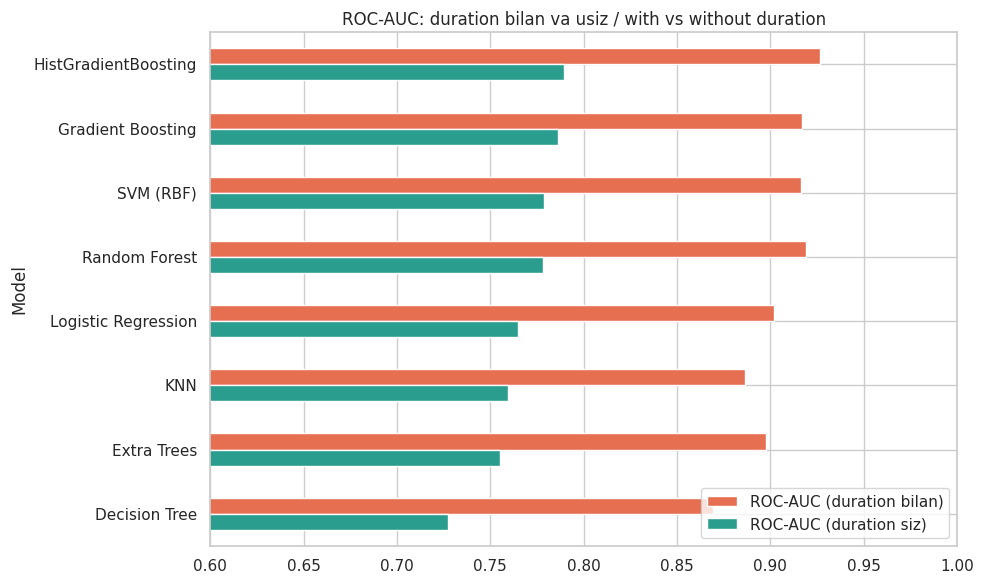

Eng yaxshi model (duration siz): HistGradientBoosting


In [8]:
cmp = res_A[['Model', 'ROC-AUC']].merge(res_B[['Model', 'ROC-AUC']], on='Model',
                                         suffixes=(' (duration bilan)', ' (duration siz)'))
cmp = cmp.set_index('Model').loc[res_B['Model']]
ax = cmp.plot(kind='barh', figsize=(10, 6), color=['#e76f51', '#2a9d8f'])
ax.invert_yaxis(); ax.set_xlim(0.6, 1.0); ax.legend(loc='lower right')
ax.set_title('ROC-AUC: duration bilan va usiz / with vs without duration')
plt.tight_layout(); plt.savefig('images/model_comparison.png', dpi=130); plt.show()

best_name = res_B.loc[0, 'Model']
RESULTS['best_model_cv'] = best_name
RESULTS['best_cv_auc'] = round(float(res_B.loc[0, 'ROC-AUC']), 4)
RESULTS['best_cv_auc_leak'] = round(float(res_A.loc[0, 'ROC-AUC']), 4)
RESULTS['cv_table_B'] = res_B.round(4).to_dict('records')
print('Eng yaxshi model (duration siz):', best_name)

**Xulosa:** `duration`ni qo'shsam, deyarli har bir model uchun AUC ~0.90+ ga chiqadi, ya'ni tahlilning "yaxshi" ko'rinishi asosan shu bitta ustun hisobiga. Usiz natija sezilarli pasayadi. Bu **haqiqiy** qiymat: mijoz bilan gaplashmasdan turib shuncha aniqlik bilan bashorat qila olamiz. Boosting asosidagi modellar odatda oddiy modellardan yaxshiroq natija beradi.

## 7-bosqich. Eng yaxshi modelni sozlash (Hyperparameter tuning)

Cross-validation'da yetakchi modelni `RandomizedSearchCV` bilan sozlayman (faqat train to'plamida).

In [9]:
cols_final = [c for c in X_train.columns if c != 'duration']

# Cross-validation'da eng yaxshi chiqqan model asosida pipeline
base_models = get_models()
pipe = Pipeline([('prep', make_preprocessor(cols_final)),
                 ('model', base_models[best_name])])

param_space = {
    'HistGradientBoosting': {
        'model__learning_rate': [0.02, 0.03, 0.05, 0.08, 0.1],
        'model__max_depth': [3, 4, 5, 6, None],
        'model__max_leaf_nodes': [15, 31, 63],
        'model__min_samples_leaf': [10, 20, 40, 80],
        'model__l2_regularization': [0.0, 0.1, 1.0, 5.0],
        'model__max_iter': [100, 200, 300]},
    'Gradient Boosting': {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.03, 0.05, 0.1],
        'model__max_depth': [2, 3, 4],
        'model__subsample': [0.7, 0.85, 1.0]},
    'Random Forest': {
        'model__n_estimators': [300, 500],
        'model__max_depth': [8, 12, 16, None],
        'model__min_samples_leaf': [1, 3, 5, 10],
        'model__max_features': ['sqrt', 0.3, 0.5]},
}
space = param_space.get(best_name, param_space['HistGradientBoosting'])

search = RandomizedSearchCV(pipe, space, n_iter=25, scoring='roc_auc', cv=cv,
                            random_state=RANDOM_STATE, n_jobs=-1)
search.fit(X_train[cols_final], y_train)

print('Eng yaxshi parametrlar:', {k.replace('model__', ''): v for k, v in search.best_params_.items()})
print(f'CV ROC-AUC (tuning dan keyin): {search.best_score_:.4f}')
RESULTS['tuned_cv_auc'] = round(float(search.best_score_), 4)
final_model = search.best_estimator_

Eng yaxshi parametrlar: {'min_samples_leaf': 40, 'max_leaf_nodes': 63, 'max_iter': 300, 'max_depth': 5, 'learning_rate': 0.05, 'l2_regularization': 0.0}
CV ROC-AUC (tuning dan keyin): 0.7936


## 8-bosqich. Test to'plamida yakuniy baholash / Final evaluation

Test to'plami birinchi marta shu yerda ishlatiladi. Taqqoslash uchun avvalgi yondashuvimni (LabelEncoder + `duration` + Random Forest) **aynan shu split**da qayta ishga tushiraman.

,Yondashuv,Accuracy,ROC-AUC
0,Avvalgi: RF + LabelEncoder + duration (leakage),0.8527,0.9155
1,Yangi: tuned HistGradientBoosting (duration siz),0.7470,0.7952



                     precision    recall  f1-score   support

Depozit ochmadi (0)       0.72      0.86      0.78      1175
  Depozit ochdi (1)       0.80      0.62      0.70      1058

           accuracy                           0.75      2233
          macro avg       0.76      0.74      0.74      2233
       weighted avg       0.76      0.75      0.74      2233



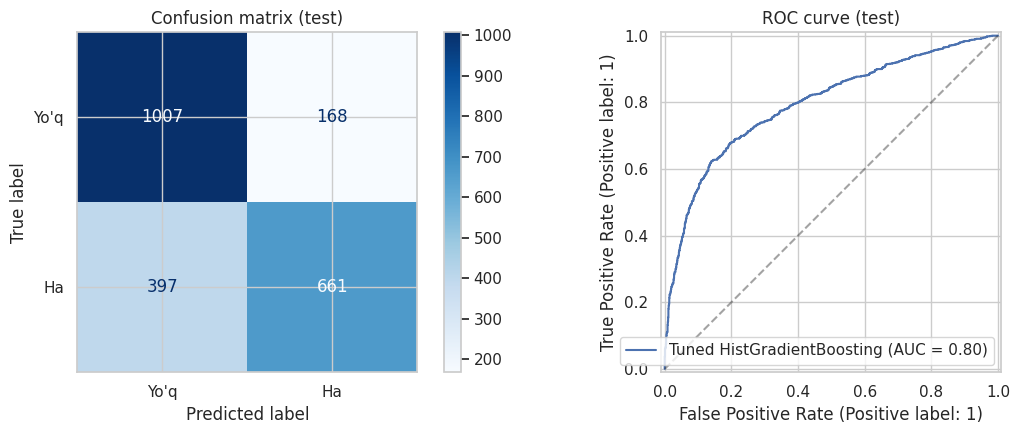

In [10]:
# --- Avvalgi yondashuv (leakage bilan), taqqoslash uchun ---
old = df.drop(columns=['target']).copy()
for c in ['deposit', 'housing', 'loan', 'default']:
    old[c] = (old[c] == 'yes').astype(int)
for c in old.select_dtypes(exclude='number').columns:
    old[c] = LabelEncoder().fit_transform(old[c])
Xo, yo = old.drop(columns='deposit'), old['deposit']
Xo_tr, Xo_te, yo_tr, yo_te = train_test_split(Xo, yo, test_size=0.2, stratify=yo, random_state=RANDOM_STATE)
old_rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE).fit(Xo_tr, yo_tr)
old_acc = accuracy_score(yo_te, old_rf.predict(Xo_te))
old_auc = roc_auc_score(yo_te, old_rf.predict_proba(Xo_te)[:, 1])

# --- Yangi yakuniy model (duration siz) ---
proba = final_model.predict_proba(X_test[cols_final])[:, 1]
pred = (proba >= 0.5).astype(int)
new_acc, new_f1, new_auc = accuracy_score(y_test, pred), f1_score(y_test, pred), roc_auc_score(y_test, proba)

summary = pd.DataFrame({
    'Yondashuv': ['Avvalgi: RF + LabelEncoder + duration (leakage)', f'Yangi: tuned {best_name} (duration siz)'],
    'Accuracy': [old_acc, new_acc], 'ROC-AUC': [old_auc, new_auc]}).round(4)
display(summary)

RESULTS.update(old_acc=round(old_acc, 4), old_auc=round(old_auc, 4),
               new_acc=round(new_acc, 4), new_auc=round(new_auc, 4), new_f1=round(new_f1, 4))

print()
print(classification_report(y_test, pred, target_names=['Depozit ochmadi (0)', 'Depozit ochdi (1)']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=['Yo\'q', 'Ha'], cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion matrix (test)')
RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1], name=f'Tuned {best_name}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=.4); axes[1].set_title('ROC curve (test)')
plt.tight_layout(); plt.savefig('images/final_evaluation.png', dpi=130); plt.show()

## 9-bosqich. Qaysi belgilar muhim? Permutation importance

Random Forest'ning `feature_importances_` ko'rsatkichi yuqori kardinalli/uzluksiz belgilarga moyil (biased). Shuning uchun test to'plamida **permutation importance** ishlataman: belgini aralashtirganda AUC qancha tushishini o'lchaydi.

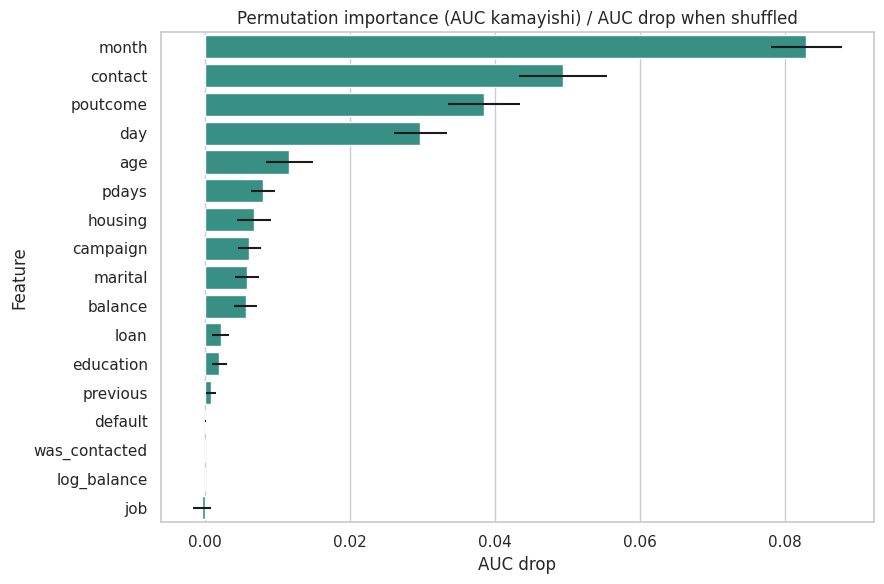

,Feature,AUC drop,std
10,month,0.0830,0.0049
8,contact,0.0494,0.0061
14,poutcome,0.0385,0.0050
9,day,0.0297,0.0036
0,age,0.0117,0.0032
12,pdays,0.0080,0.0017
6,housing,0.0068,0.0023
11,campaign,0.0061,0.0016


In [11]:
perm = permutation_importance(final_model, X_test[cols_final], y_test, scoring='roc_auc',
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
imp = (pd.DataFrame({'Feature': cols_final, 'AUC drop': perm.importances_mean, 'std': perm.importances_std})
         .sort_values('AUC drop', ascending=False))

plt.figure(figsize=(9, 6))
sns.barplot(data=imp, x='AUC drop', y='Feature', color='#2a9d8f', xerr=imp['std'].values)
plt.title('Permutation importance (AUC kamayishi) / AUC drop when shuffled')
plt.tight_layout(); plt.savefig('images/permutation_importance.png', dpi=130); plt.show()
RESULTS['top_features'] = imp['Feature'].head(5).tolist()
imp.head(8).round(4)

## 10-bosqich. Biznes natijasi: Gain va Lift

Bank uchun asosiy savol: *"Agar mijozlarning faqat bir qismiga qo'ng'iroq qilsam, depozit ochadiganlarning qanchasini ushlab olaman?"* Test mijozlarini model ehtimolligi bo'yicha tartiblab, 10 ta guruhga (decile) bo'laman.

,count,depozit_ochgan,conversion_%,cum_capture_%,lift
decile,,,,,
1,224,208,92.9,19.7,1.96
2,223,184,82.5,37.1,1.74
3,223,168,75.3,52.9,1.59
4,223,126,56.5,64.8,1.19
5,224,94,42.0,73.7,0.89
6,223,74,33.2,80.7,0.70
7,223,63,28.3,86.7,0.60
8,223,55,24.7,91.9,0.52
9,223,49,22.0,96.5,0.46


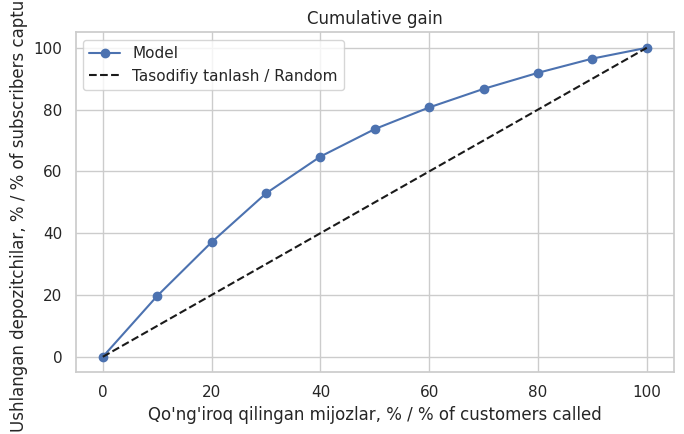

In [12]:
gain = pd.DataFrame({'y': y_test.values, 'p': proba}).sort_values('p', ascending=False).reset_index(drop=True)
gain['decile'] = pd.qcut(gain.index, 10, labels=range(1, 11))
tab = gain.groupby('decile', observed=True)['y'].agg(['count', 'sum']).rename(columns={'sum': 'depozit_ochgan'})
tab['conversion_%'] = (tab['depozit_ochgan'] / tab['count'] * 100).round(1)
tab['cum_capture_%'] = (tab['depozit_ochgan'].cumsum() / tab['depozit_ochgan'].sum() * 100).round(1)
tab['lift'] = (tab['conversion_%'] / (y_test.mean() * 100)).round(2)
display(tab)

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(0, 101, 10)
ax.plot(x, [0] + tab['cum_capture_%'].tolist(), marker='o', label='Model')
ax.plot(x, x, 'k--', label='Tasodifiy tanlash / Random')
ax.set_xlabel('Qo\'ng\'iroq qilingan mijozlar, % / % of customers called')
ax.set_ylabel('Ushlangan depozitchilar, % / % of subscribers captured')
ax.set_title('Cumulative gain'); ax.legend()
plt.tight_layout(); plt.savefig('images/gain_chart.png', dpi=130); plt.show()

RESULTS['capture_top30'] = float(tab.loc[3, 'cum_capture_%'])
RESULTS['capture_top50'] = float(tab.loc[5, 'cum_capture_%'])
RESULTS['lift_top10'] = float(tab.loc[1, 'lift'])

## 11-bosqich. Modelni saqlash va natijalar / Save model & results

In [13]:
joblib.dump(final_model, 'bank_deposit_model.joblib')
with open('results.json', 'w') as f:
    json.dump(RESULTS, f, ensure_ascii=False, indent=2)

print('✅ Model saqlandi: bank_deposit_model.joblib')
print(json.dumps({k: v for k, v in RESULTS.items() if k != 'cv_table_B'}, ensure_ascii=False, indent=2))

✅ Model saqlandi: bank_deposit_model.joblib
{
  "best_model_cv": "HistGradientBoosting",
  "best_cv_auc": 0.7896,
  "best_cv_auc_leak": 0.9264,
  "tuned_cv_auc": 0.7936,
  "old_acc": 0.8527,
  "old_auc": 0.9155,
  "new_acc": 0.747,
  "new_auc": 0.7952,
  "new_f1": 0.7006,
  "top_features": [
    "month",
    "contact",
    "poutcome",
    "day",
    "age"
  ],
  "capture_top30": 52.9,
  "capture_top50": 73.7,
  "lift_top10": 1.96
}


## 🎯 Yakuniy xulosa / Conclusion

| | Avvalgi versiya | Yangi versiya |
|---|---|---|
| Algoritmlar | 1 ta (Random Forest) | 8 ta, cross-validation bilan |
| Kodlash | `LabelEncoder` (hammasiga) | `OneHotEncoder` + `StandardScaler`, Pipeline ichida |
| `duration` | ishlatilgan (leakage) | olib tashlangan |
| Baholash | faqat Accuracy | Accuracy, F1, ROC-AUC, confusion matrix, gain/lift |
| Tuning | yo'q | RandomizedSearchCV |
| Test AUC | 0.9155 (leakage) | **0.7952** |

- **Eng yaxshi model:** tuned **HistGradientBoosting**, test ROC-AUC ≈ **0.7952**, accuracy ≈ **0.747**.
- **Biznes ma'nosi:** mijozlarning eng yuqori ball olgan 30% iga qo'ng'iroq qilsak, depozit ochadiganlarning taxminan **52.9%** ini ushlaymiz (tasodifiy tanlashda 30%).
- **Eng muhim belgilar:** month, contact, poutcome, day, age.

### Cheklovlar va keyingi qadamlar / Limitations & next steps
- `month` va `day` eng muhim belgilar qatorida: bu mijoz xususiyati emas, balki **kampaniya vaqti** signali (ba'zi oylarda namuna juda kichik, masalan dekabrda ~110 ta qator). Shuning uchun ularga ehtiyot bo'lib yondashish kerak.
- Dataset bitta bank va bitta davrga tegishli, shuning uchun boshqa bozorga o'tkazishda model qayta o'qitilishi kerak.
- `month`/`day` vaqtga bog'liq belgilar. Real tizimda **vaqt bo'yicha bo'lingan** (time-based) validatsiya ishonchliroq bo'ladi.
- Narx-foyda asosida threshold tanlash (qo'ng'iroq narxi va depozit daromadiga qarab) qo'shilishi mumkin.
- SHAP bilan har bir mijoz uchun tushuntirish qo'shish mumkin.